# Inter-Subset Analysis

For datasets with pre-defined subsets, this notebook analyzes the differences between:

1. Model ranking across the full dataset and model ranking for each subset
2. Model performance across the full dataset and performance for each subset

Import packages.

In [717]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from utils.data import (
    Dataset,
    MetadataKey,
    get_metadata_mask,
    get_unique_metadata_values,
)
from utils.model import load_eval_results, compute_ranking
from utils.path import resolve_dataset_path, build_plot_path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


View each dataset's columns to determine which ones have pre-defined subsets.

In [718]:
datasets = [d.value for d in Dataset]

for dataset in datasets:
    file_path = resolve_dataset_path(dataset)
    df = pd.read_json(file_path)
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

DS-1000: 1000 instances


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


MATH: 5000 instances


,problem,level,type,solution,subset
0,How many vertical asymptotes does the graph of...,Level 3,Algebra,The denominator of the rational function facto...,algebra
1,What is the positive difference between $120\%...,Level 1,Algebra,One hundred twenty percent of 30 is $120\cdot3...,algebra
2,Find $x$ such that $\lceil x \rceil + x = \dfr...,Level 4,Algebra,"First, we note that $x$ must be positive, sinc...",algebra
3,Evaluate $i^5+i^{-25}+i^{45}$.,Level 5,Algebra,We have $i^5 = i^4\cdot i = 1\cdot (i) = i$. ...,algebra
4,"If $2^8=4^x$, what is the value of $x$?",Level 1,Algebra,Rewrite $4$ as $2^2$ to find $4^x=2^{2x}$. Si...,algebra


MMLU: 14042 instances


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1


**Note:** For DS-1000, we'll categorize instances based on the library that's used (e.g., numpy, pandas, etc.).

## DS-1000

Load the raw dataset and evaluation results.

In [719]:
dataset = Dataset.DS_1000
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
models = eval_results_df.columns.tolist()

num_instances, num_models = len(dataset_df), len(models)

print(f"Number of instances: {num_instances}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {num_models}")
display(eval_results_df.head())

Number of instances: 1000


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 3


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


### Ranking Analysis

Compute the global model ranking.

In [720]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

deepseek-coder-6.7b-base: 3
gpt-3.5-turbo-0613: 2
gpt-4o-2024-08-06: 1


Count the number of subsets where the local model ranking differs from the global model ranking.

In [721]:
subset_col = MetadataKey.LIBRARY
subsets = get_unique_metadata_values(dataset_df, subset_col)
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from global ranking: {num_different}")

Subsets: {'Tensorflow', 'Sklearn', 'Matplotlib', 'Numpy', 'Scipy', 'Pytorch', 'Pandas'}
Total number of subsets: 7
Subsets that differ from global ranking: 1


Compute the Kendall's Tau between each subset's local model ranking and the global model ranking. 

In [722]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": len(subset_eval_results_df),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Computing model rankings: 100%|██████████| 7/7 [00:00<00:00, 383.62subset/s]


,subset,ranking,kendall_tau,n_instances
0,Tensorflow,"[3, 2, 1]",1.000000,45
1,Sklearn,"[2, 3, 1]",0.333333,115
2,Matplotlib,"[3, 2, 1]",1.000000,155
3,Numpy,"[3, 2, 1]",1.000000,220
4,Scipy,"[3, 2, 1]",1.000000,106


Plot the distribution of Kendall's Taus between each subset's local model ranking and the global model ranking.

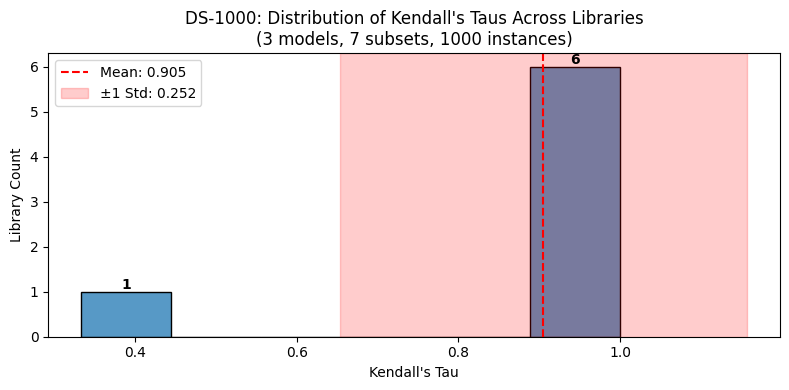

In [723]:
# Compute mean and std
mean_tau = kendall_tau_df["kendall_tau"].mean()
std_tau = kendall_tau_df["kendall_tau"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=kendall_tau_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel(f"{subset_col.capitalize()} Count")
ax.set_title(
    f"{dataset}: Distribution of Kendall's Taus Across Libraries"
    f"\n({num_models} models, {len(subsets)} subsets, {num_instances} instances)"
)

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.legend()
plt.tight_layout()

analysis = "subset_analysis"
plot_name = f"kendall_tau_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

#### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [724]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

,model,accuracy
2,gpt-4o-2024-08-06,0.598
1,gpt-3.5-turbo-0613,0.387
0,deepseek-coder-6.7b-base,0.312


Compute each model's mean performance on each subset.

In [725]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_eval_results_df = eval_results_df[mask]
    accuracy_results[subset] = subset_eval_results_df.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Computing mean performance: 100%|██████████| 7/7 [00:00<00:00, 420.27subset/s]


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
subset,,,
Tensorflow,0.222222,0.333333,0.488889
Sklearn,0.382609,0.356522,0.513043
Matplotlib,0.522581,0.593548,0.754839
Numpy,0.354545,0.368182,0.700000
Scipy,0.245283,0.396226,0.613208


Plot the distribution of each model's mean performance across the different subsets.

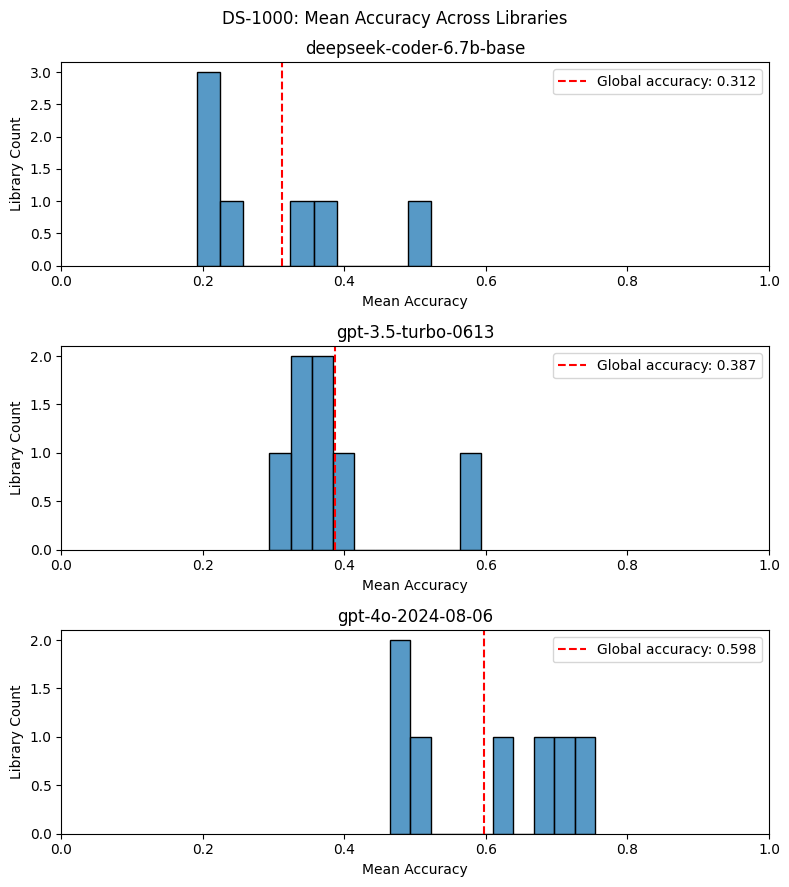

In [726]:
global_means = eval_results_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    ax = axes[i] if num_models > 1 else axes
    sns.histplot(data=accuracy_df, x=model, ax=ax, bins=10)
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel(f"{subset_col.capitalize()} Count")
    ax.set_title(f"{model}")
    ax.set_xlim(0, 1)

    # Add vertical line for global mean
    global_mean = global_means[model]
    ax.axvline(
        global_mean,
        color="red",
        linestyle="--",
        label=f"Global accuracy: {global_mean:.3f}",
    )
    ax.legend()

plt.suptitle(f"{dataset}: Mean Accuracy Across Libraries")
plt.tight_layout()
plot_name = f"accuracy_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### MATH

Load the raw dataset and evaluation results.

In [727]:
dataset = Dataset.MATH
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
# eval_results_df = eval_results_df.drop(columns=["gpt-4o-mini-2024-07-18"])
models = eval_results_df.columns.tolist()

num_instances, num_models = len(dataset_df), len(models)

print(f"Number of instances: {num_instances}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {num_models}")
display(eval_results_df.head())

Number of instances: 5000


,problem,level,type,solution,subset
0,How many vertical asymptotes does the graph of...,Level 3,Algebra,The denominator of the rational function facto...,algebra
1,What is the positive difference between $120\%...,Level 1,Algebra,One hundred twenty percent of 30 is $120\cdot3...,algebra
2,Find $x$ such that $\lceil x \rceil + x = \dfr...,Level 4,Algebra,"First, we note that $x$ must be positive, sinc...",algebra
3,Evaluate $i^5+i^{-25}+i^{45}$.,Level 5,Algebra,We have $i^5 = i^4\cdot i = 1\cdot (i) = i$. ...,algebra
4,"If $2^8=4^x$, what is the value of $x$?",Level 1,Algebra,Rewrite $4$ as $2^2$ to find $4^x=2^{2x}$. Si...,algebra


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 5


,dart-math-llama3-8b-uniform,deepseek-math-7b-instruct,gpt-4o-mini-2024-07-18,Llama-3-8B-Instruct,Llama-3.1-8B-Instruct
0,1,1,1,1,1
1,1,1,1,0,1
2,0,1,1,1,0
3,1,0,1,0,1
4,1,1,1,1,1


#### Ranking Analysis

Compute the global model ranking.

In [728]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

dart-math-llama3-8b-uniform: 4
deepseek-math-7b-instruct: 3
gpt-4o-mini-2024-07-18: 1
Llama-3-8B-Instruct: 5
Llama-3.1-8B-Instruct: 2


Count the number of subsets where the local model ranking differs from the global model ranking.

In [729]:
subset_col = "subset"
subsets = dataset_df[subset_col].unique().tolist()
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Subsets: ['algebra', 'counting_and_probability', 'geometry', 'intermediate_algebra', 'number_theory', 'prealgebra', 'precalculus']
Total number of subsets: 7
Subsets that differ from the global ranking: 4


Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [730]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Computing model rankings: 100%|██████████| 7/7 [00:00<?, ?subset/s]


,subset,ranking,kendall_tau,n_instances
0,algebra,"[4, 3, 1, 5, 2]",1.0,1187
1,counting_and_probability,"[4, 3, 1, 5, 2]",1.0,474
2,geometry,"[4, 2, 1, 5, 3]",0.8,479
3,intermediate_algebra,"[3, 4, 1, 5, 2]",0.8,903
4,number_theory,"[3, 4, 1, 5, 2]",0.8,540


Plot the distribution of Kendall's Taus between each subset's model ranking and the global model ranking.

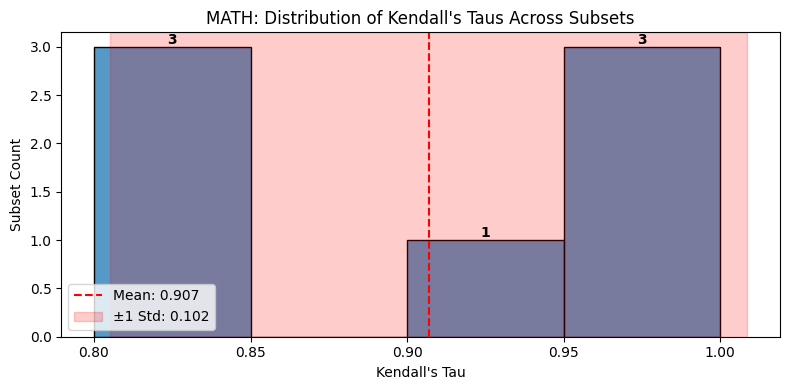

In [731]:
# Compute mean and std
mean_tau = kendall_tau_df["kendall_tau"].mean()
std_tau = kendall_tau_df["kendall_tau"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=kendall_tau_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel(f"{subset_col.capitalize()} Count")

without_gpt_4o_mini = "gpt-4o-mini-2024-07-18" not in models
note = " (without gpt-4o-mini-2024-07-18)" if without_gpt_4o_mini else ""
ax.set_title(
    f"{dataset}: Distribution of Kendall's Taus Across {subset_col.capitalize()}s{note}"
)

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.legend()
plt.tight_layout()

suffix = "_without_gpt-4o-mini-2024-07-18" if without_gpt_4o_mini else ""
plot_name = f"kendall_tau_distribution{suffix}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

#### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [732]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

,model,accuracy
2,gpt-4o-mini-2024-07-18,0.701
4,Llama-3.1-8B-Instruct,0.497
1,deepseek-math-7b-instruct,0.470
0,dart-math-llama3-8b-uniform,0.453
3,Llama-3-8B-Instruct,0.301


Compute each model's mean performance on each subset.

In [733]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    accuracy_results[subset] = subset_eval_results_df.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Computing mean performance: 100%|██████████| 7/7 [00:00<00:00, 1671.13subset/s]


,dart-math-llama3-8b-uniform,deepseek-math-7b-instruct,gpt-4o-mini-2024-07-18,Llama-3-8B-Instruct,Llama-3.1-8B-Instruct
subset,,,,,
algebra,0.665543,0.691660,0.882056,0.444819,0.717776
counting_and_probability,0.345992,0.375527,0.725738,0.223629,0.426160
geometry,0.323591,0.382046,0.565762,0.208768,0.377871
intermediate_algebra,0.253599,0.225914,0.460687,0.130676,0.260244
number_theory,0.357407,0.353704,0.725926,0.231481,0.444444


Plot the distribution of each model's mean performance across the different subsets.

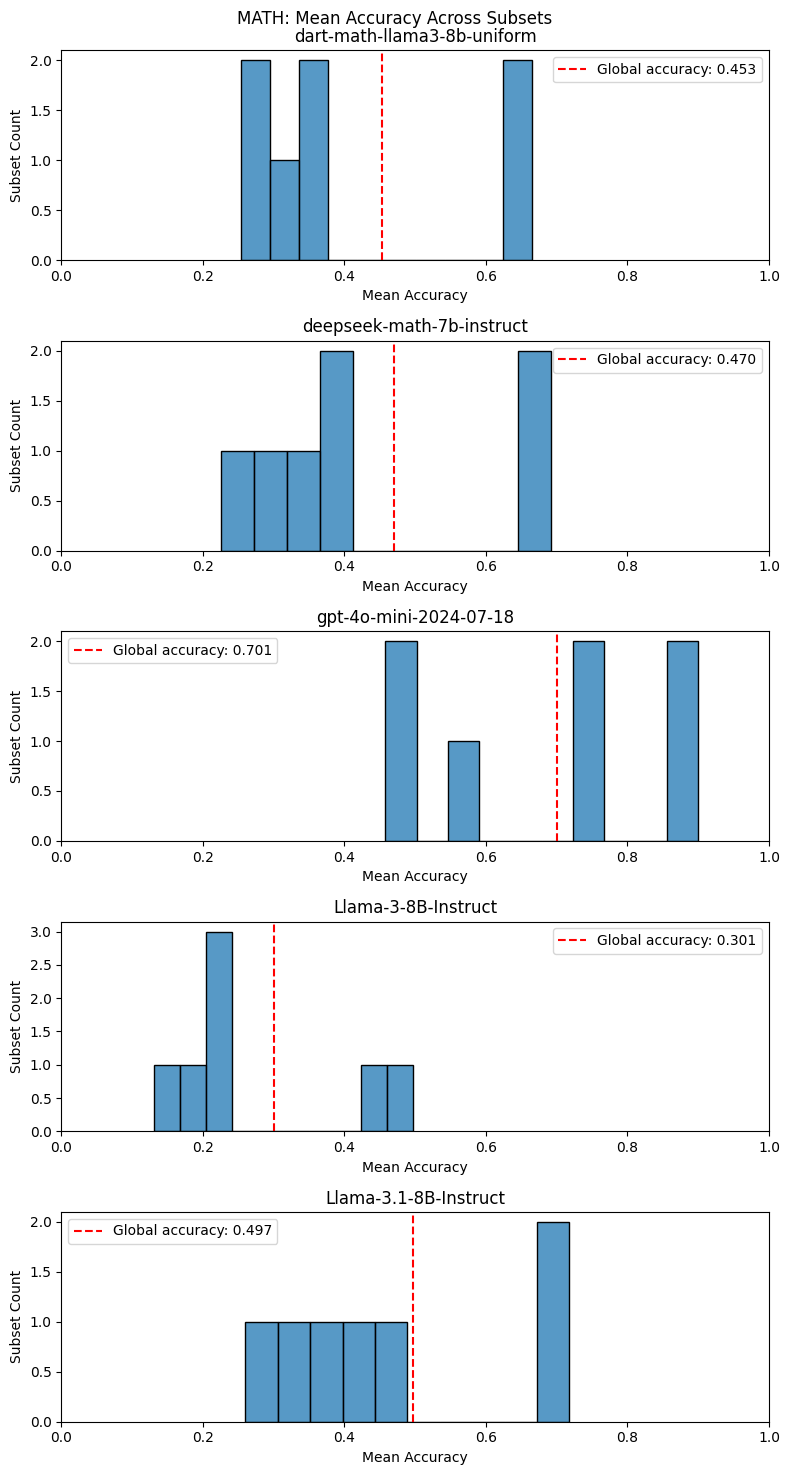

In [734]:
global_means = eval_results_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    ax = axes[i] if num_models > 1 else axes
    sns.histplot(data=accuracy_df, x=model, ax=ax, bins=10)
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel(f"{subset_col.capitalize()} Count")
    ax.set_title(f"{model}")
    ax.set_xlim(0, 1)

    # Add vertical line for global mean
    global_mean = global_means[model]
    ax.axvline(
        global_mean,
        color="red",
        linestyle="--",
        label=f"Global accuracy: {global_mean:.3f}",
    )
    ax.legend()

plt.suptitle(f"{dataset}: Mean Accuracy Across {subset_col.capitalize()}s")
plt.tight_layout()
plot_name = f"accuracy_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### MMLU

Load the raw dataset and evaluation results.

In [735]:
dataset = Dataset.MMLU
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
models = eval_results_df.columns.tolist()

num_instances, num_models = len(dataset_df), len(models)

print(f"Number of instances: {num_instances}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {num_models}")
display(eval_results_df.head())

Number of instances: 14042


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 9


,claude-3.5-haiku,gpt-3.5-turbo,gpt-4o-mini-2024-07-18,Llama-3.1-70B-Instruct,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-70B,Llama-3.1-Tulu-3-8B,Qwen2.5-72B-Instruct,Qwen2.5-7B-Instruct
0,1,0,1,1,0,1,0,1,0
1,0,0,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1
4,1,0,1,1,1,1,0,1,1


#### Ranking Analysis

Compute the global model ranking.

In [736]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

claude-3.5-haiku: 5
gpt-3.5-turbo: 8
gpt-4o-mini-2024-07-18: 4
Llama-3.1-70B-Instruct: 1
Llama-3.1-8B-Instruct: 7
Llama-3.1-Tulu-3-70B: 3
Llama-3.1-Tulu-3-8B: 9
Qwen2.5-72B-Instruct: 2
Qwen2.5-7B-Instruct: 6


Count the number of subsets where the local model ranking differs from the global model ranking.

In [737]:
subset_col = "subject"
subsets = dataset_df[subset_col].unique().tolist()
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Subsets: ['abstract_algebra', 'anatomy', 'astronomy', 'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 'college_computer_science', 'college_mathematics', 'college_medicine', 'college_physics', 'computer_security', 'conceptual_physics', 'econometrics', 'electrical_engineering', 'elementary_mathematics', 'formal_logic', 'global_facts', 'high_school_biology', 'high_school_chemistry', 'high_school_computer_science', 'high_school_european_history', 'high_school_geography', 'high_school_government_and_politics', 'high_school_macroeconomics', 'high_school_mathematics', 'high_school_microeconomics', 'high_school_physics', 'high_school_psychology', 'high_school_statistics', 'high_school_us_history', 'high_school_world_history', 'human_aging', 'human_sexuality', 'international_law', 'jurisprudence', 'logical_fallacies', 'machine_learning', 'management', 'marketing', 'medical_genetics', 'miscellaneous', 'moral_disputes', 'moral_scenarios', 'nutrition', 'philosophy'

Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [738]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Computing model rankings: 100%|██████████| 57/57 [00:00<00:00, 897.93subset/s]


,subset,ranking,kendall_tau,n_instances
0,abstract_algebra,"[4, 8, 3, 2, 7, 4, 9, 1, 6]",0.873326,100
1,anatomy,"[5, 6, 1, 4, 7, 3, 9, 2, 8]",0.555556,135
2,astronomy,"[4, 9, 5, 2, 8, 1, 7, 3, 6]",0.722222,152
3,business_ethics,"[6, 7, 4, 1, 8, 2, 8, 2, 4]",0.841375,100
4,clinical_knowledge,"[5, 8, 4, 1, 7, 3, 9, 2, 6]",1.000000,265


Plot the distribution of Kendall's Taus between each subset's model ranking and the full dataset's model ranking.

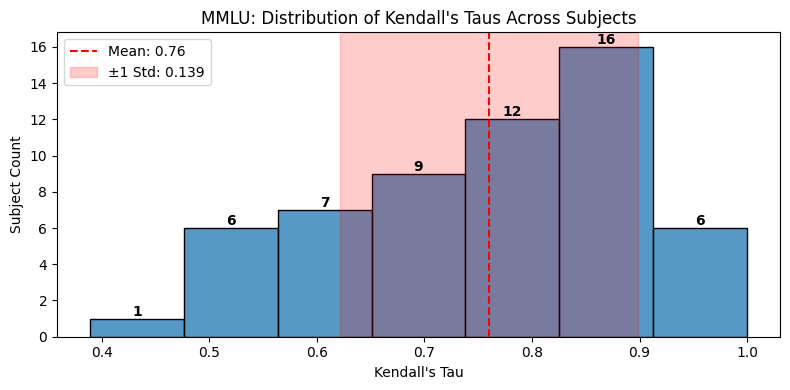

In [739]:
# Compute mean and std
mean_tau = kendall_tau_df["kendall_tau"].mean()
std_tau = kendall_tau_df["kendall_tau"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=kendall_tau_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel(f"{subset_col.capitalize()} Count")
ax.set_title(
    f"{dataset}: Distribution of Kendall's Taus Across {subset_col.capitalize()}s"
)

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.legend()
plt.tight_layout()
plot_name = "kendall_tau_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

#### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [740]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

,model,accuracy
3,Llama-3.1-70B-Instruct,0.853
7,Qwen2.5-72B-Instruct,0.850
5,Llama-3.1-Tulu-3-70B,0.819
2,gpt-4o-mini-2024-07-18,0.809
0,claude-3.5-haiku,0.808


Compute each model's mean performance on each subset.

In [741]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    accuracy_results[subset] = subset_eval_results_df.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Computing mean performance: 100%|██████████| 57/57 [00:00<00:00, 3257.29subset/s]


,claude-3.5-haiku,gpt-3.5-turbo,gpt-4o-mini-2024-07-18,Llama-3.1-70B-Instruct,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-70B,Llama-3.1-Tulu-3-8B,Qwen2.5-72B-Instruct,Qwen2.5-7B-Instruct
subset,,,,,,,,,
abstract_algebra,0.660000,0.410000,0.670000,0.740000,0.430000,0.660000,0.350000,0.780000,0.640000
anatomy,0.770370,0.733333,0.837037,0.800000,0.725926,0.822222,0.696296,0.829630,0.718519
astronomy,0.907895,0.743421,0.888158,0.934211,0.763158,0.940789,0.776316,0.927632,0.835526
business_ethics,0.760000,0.720000,0.780000,0.820000,0.700000,0.800000,0.700000,0.800000,0.780000
clinical_knowledge,0.837736,0.762264,0.849057,0.871698,0.773585,0.856604,0.754717,0.860377,0.815094


Plot the distribution of each model's performance across the different subsets.

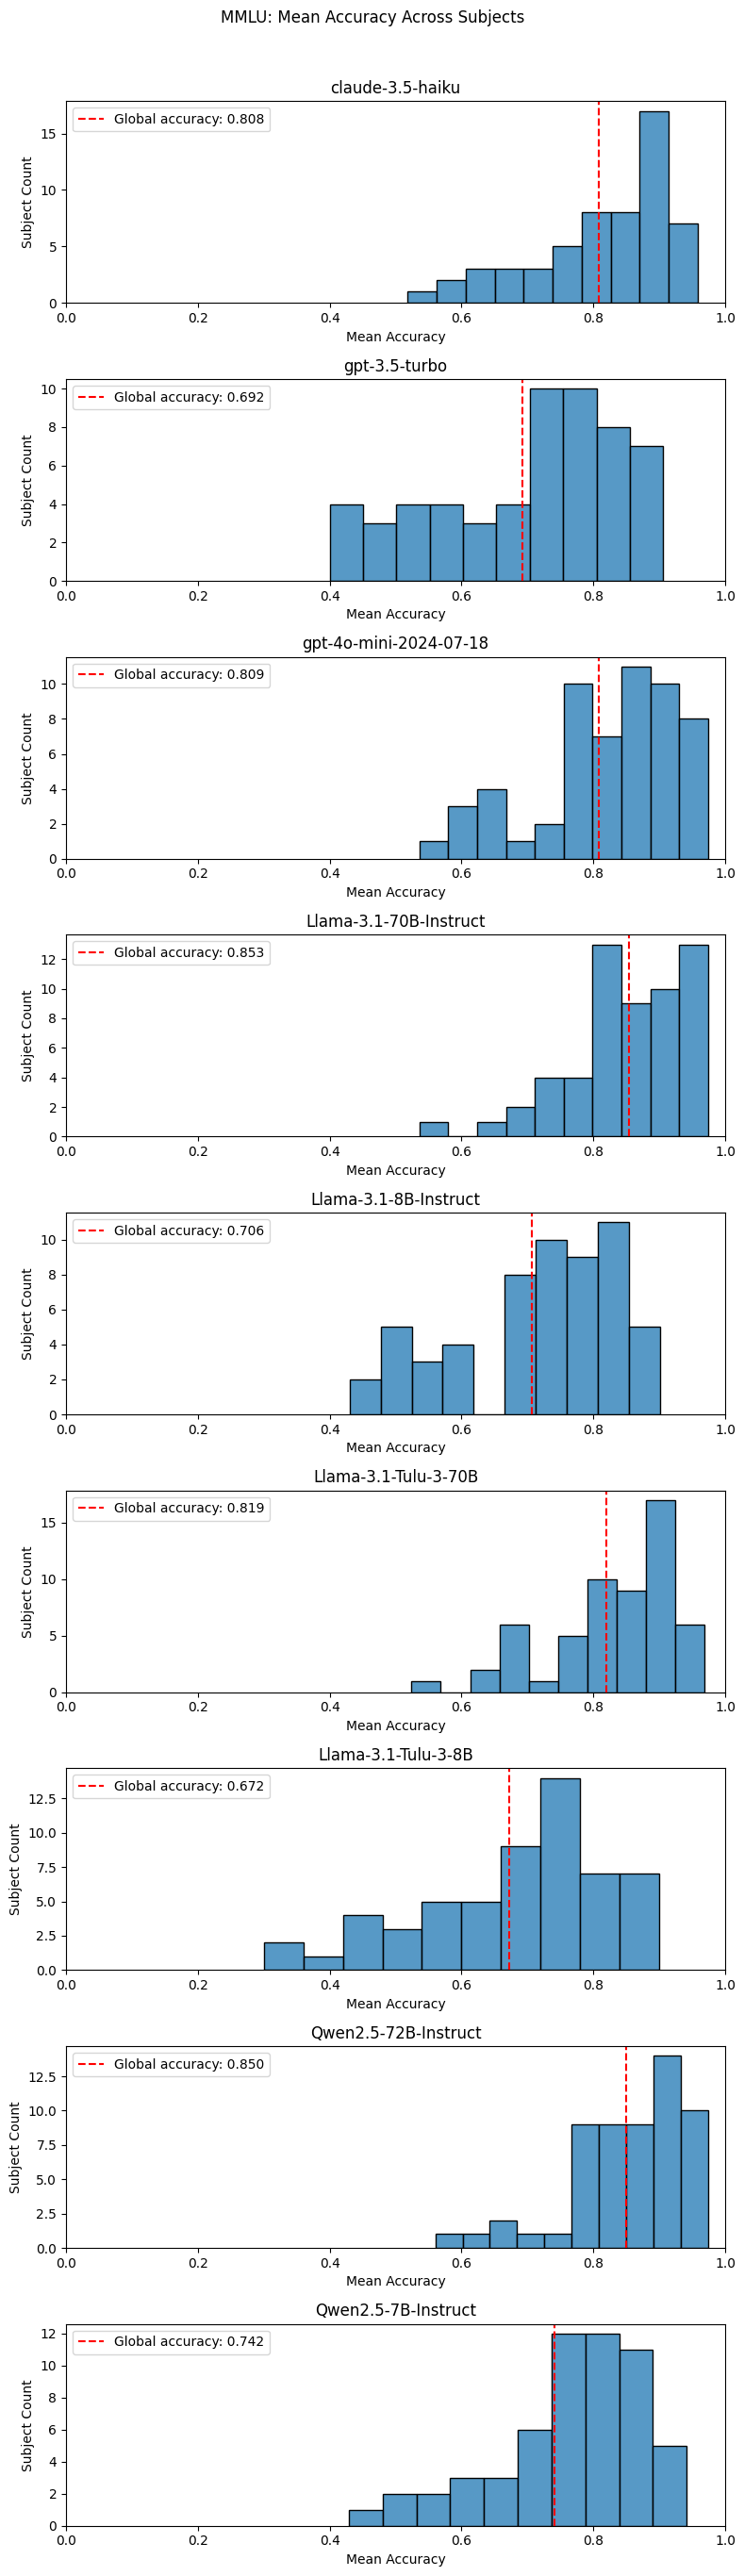

In [742]:
global_means = eval_results_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    ax = axes[i] if num_models > 1 else axes
    sns.histplot(data=accuracy_df, x=model, ax=ax, bins=10)
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel(f"{subset_col.capitalize()} Count")
    ax.set_title(f"{model}")
    ax.set_xlim(0, 1)

    # Add vertical line for global mean
    global_mean = global_means[model]
    ax.axvline(
        global_mean,
        color="red",
        linestyle="--",
        label=f"Global accuracy: {global_mean:.3f}",
    )
    ax.legend()

plt.suptitle(
    f"{dataset}: Mean Accuracy Across {subset_col.capitalize()}s",
    y=1.01,
)
plt.tight_layout()
plot_name = "accuracy_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()